<a href="https://colab.research.google.com/github/anujjakhotiya/AI-DL_2026/blob/main/lab_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [100/1000], Loss: 0.6329
Epoch [200/1000], Loss: 0.4290
Epoch [300/1000], Loss: 0.3985
Epoch [400/1000], Loss: 0.3896
Epoch [500/1000], Loss: 0.3830
Epoch [600/1000], Loss: 0.3771
Epoch [700/1000], Loss: 0.3706
Epoch [800/1000], Loss: 0.3645
Epoch [900/1000], Loss: 0.3588
Epoch [1000/1000], Loss: 0.3529

Evaluation Results
Accuracy : 0.8100558659217877
Precision: 0.7966101694915254
Recall   : 0.6811594202898551
F1 Score : 0.734375

Confusion Matrix
[[98 12]
 [22 47]]


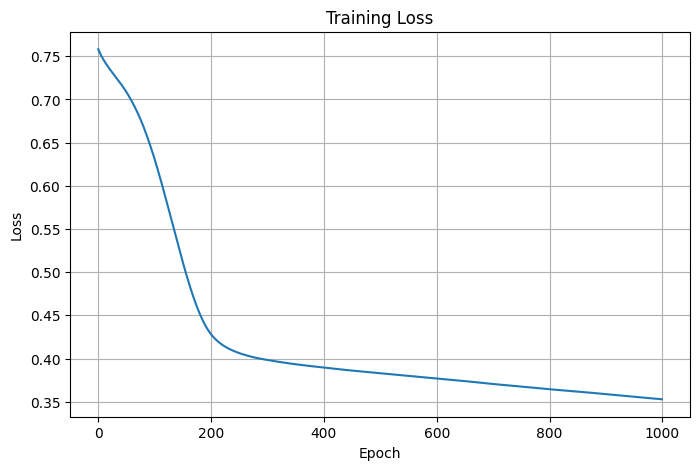

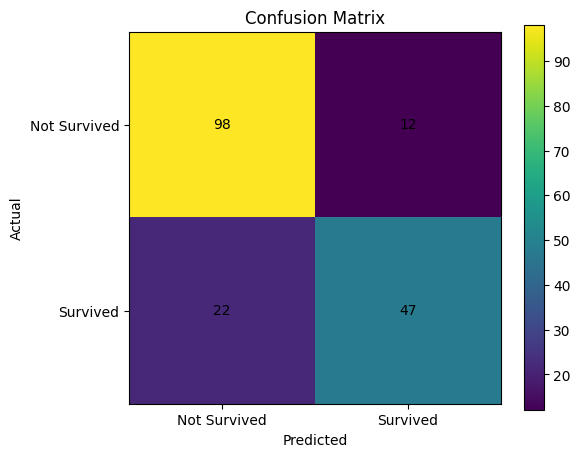

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("Titanic-Dataset.csv")

df = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Survived"]]
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

X = df.drop("Survived", axis=1).values
y = df["Survived"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
losses = []

for epoch in range(epochs):
    output = model(X_train)
    loss = criterion(output, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

with torch.no_grad():
    probabilities = model(X_test)
    predictions = (probabilities >= 0.5).float()

y_test_np = y_test.numpy()
predictions_np = predictions.numpy()

print("\nEvaluation Results")
print("Accuracy :", accuracy_score(y_test_np, predictions_np))
print("Precision:", precision_score(y_test_np, predictions_np))
print("Recall   :", recall_score(y_test_np, predictions_np))
print("F1 Score :", f1_score(y_test_np, predictions_np))

cm = confusion_matrix(y_test_np, predictions_np)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])
plt.show()